# Data Preprocessing Lab: Getting Data ML-Ready

## Student Practice Notebook

**Name:** K YUVANYA  
**Register Number:** AP24110010974

**Date:**  22-08-2026

## Learning Objectives

After completing this lab, you will be able to:

- Handle missing data with justified strategies (not just delete-everything)
- Encode categorical variables into numeric form (label encoding, one-hot encoding)
- Scale/normalize numeric features (min-max scaling, standardization)
- Detect and handle outliers
- Split data into train/test sets correctly
- Apply preprocessing to image data (pixel normalization) and text data (numeric encoding)

### Why this week matters
Every ML model needs **numbers, on a similar scale, with no gaps**. Raw pandas data (mixed types, missing values, unscaled numbers) can't go directly into a model. This lab is the bridge between "clean data" (last week) and "model-ready data" (next steps in your course).

### How to use this notebook
Same as before: **demo → practice → predict-then-run → reflect.**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147


## Part 1: Missing Data — Choosing a Strategy

Last week you dropped or filled missing values without much thought about *which* to choose. This week: which strategy is right depends on the situation.

### Demonstration


In [ ]:
tips_missing = tips.copy()
np.random.seed(42)
missing_idx = np.random.choice(tips_missing.index, size=15, replace=False)
tips_missing.loc[missing_idx, 'total_bill'] = np.nan

print("Missing values:", tips_missing['total_bill'].isna().sum())
print("Percentage missing: {:.1f}%".format(100 * tips_missing['total_bill'].isna().sum() / len(tips_missing)))


Missing values: 15
Percentage missing: 6.1%


**Common strategies:**
- **Drop rows** — safe when missing % is small AND rows are random (not systematically missing)
- **Fill with mean/median** — good for numeric columns; median is safer when outliers exist
- **Fill with mode** — for categorical columns
- **Fill with group-wise mean** — smarter: fill using the mean *within a relevant group* instead of the global mean

### Demonstration: group-wise fill (smarter than global mean)


In [ ]:
# Instead of filling with the overall mean, fill using each day's own mean
# This preserves day-to-day differences instead of flattening everything to one number

day_means = tips_missing.groupby('day')['total_bill'].transform('mean')
tips_filled = tips_missing.copy()
tips_missing_filled_bill = tips_missing['total_bill'].fillna(day_means)
tips_filled['total_bill'] = tips_missing_filled_bill

print("Remaining missing:", tips_filled['total_bill'].isna().sum())


Remaining missing: 0


### Student Practice

1. Create missing values in the `tip` column (5 random rows) the same way as the demo.
2. Fill them using the **median** `tip` grouped by `time` (Lunch/Dinner) instead of by day.
3. In 1-2 sentences, justify why you chose group-by-`time` over a global fill for this column.


In [ ]:
tips_practice = tips.copy()
np.random.seed(42)
missing_idx_tip = np.random.choice(tips_practice.index, size=5, replace=False)
tips_practice.loc[missing_idx_tip, 'tip'] = np.nan

print("Missing values in 'tip':", tips_practice['tip'].isna().sum())


Missing values in 'tip': 5


In [ ]:
time_medians = tips_practice.groupby('time')['tip'].transform('median')

tips_practice['tip'] = tips_practice['tip'].fillna(time_medians)

print("Remaining missing in 'tip':", tips_practice['tip'].isna().sum())


Remaining missing in 'tip': 0


In [ ]:
3 ) Answer: I choose group-by-time because tipping behavior differs between Lunch and Dinner.
Using each time’s median preserves this natural variation, whereas a global fill would flatten differences.

**Reflection:** Why might filling missing values with a *group-wise* mean/median be better than a single global mean? Give a concrete scenario where this would matter.

**Your answer:**
group‑wise fills maintain subgroup integrity, while global fills risk flattening important differences.


## Part 2: Encoding Categorical Variables

ML models need numbers — they can't use `"Male"`, `"Sun"`, `"Yes"` directly. We need to **encode** categories into numeric form.

### 2a. Label Encoding (for ordinal/binary categories)

### Demonstration


In [ ]:
tips_enc = tips.copy()

# Binary categories: map directly to 0/1
tips_enc['sex_encoded'] = tips_enc['sex'].map({'Male': 0, 'Female': 1})
tips_enc['smoker_encoded'] = tips_enc['smoker'].map({'No': 0, 'Yes': 1})

tips_enc[['sex','sex_encoded','smoker','smoker_encoded']].head()


,sex,sex_encoded,smoker,smoker_encoded
0,Female,1,No,0
1,Male,0,No,0
2,Male,0,No,0
3,Male,0,No,0
4,Female,1,No,0


### 2b. One-Hot Encoding (for categories with no natural order)

`day` has 4 categories with no inherent ranking (Thur isn't "less than" Fri). Label encoding (0,1,2,3) would wrongly imply an order. **One-hot encoding** creates a separate 0/1 column per category instead.

### Demonstration


In [ ]:
day_dummies = pd.get_dummies(tips_enc['day'], prefix='day')
tips_enc = pd.concat([tips_enc, day_dummies], axis=1)
tips_enc[['day','day_Thur','day_Fri','day_Sat','day_Sun']].head()


,day,day_Thur,day_Fri,day_Sat,day_Sun
0,Sun,False,False,False,True
1,Sun,False,False,False,True
2,Sun,False,False,False,True
3,Sun,False,False,False,True
4,Sun,False,False,False,True


### Student Practice — predict then check

`time` has 2 categories (Lunch, Dinner). Predict: should you use label encoding or one-hot encoding for `time`, and why? Write your prediction, then implement whichever you chose.

**Your prediction:**
I will use label encoding for the time column because it has only two categories (Lunch and Dinner). Since it’s a binary variable, one column with values 0 and 1 is enough to represent it. One-hot encoding would create two columns, which is redundant and unnecessary here.


**Reflection:** Why would label-encoding `day` as Thur=0, Fri=1, Sat=2, Sun=3 be misleading to a model, even though it's technically valid Python code?

**Your answer:**
Label‑encoding the days as numbers is misleading because it makes the model think the days have an order or ranking. The model could assume Sunday (3) is “greater” than Thursday (0) or that the difference between Friday and Saturday is the same as between Saturday and Sunday. In reality, days are just names, not numbers, so one‑hot encoding is the better choice.


## Part 3: Feature Scaling

`total_bill` ranges roughly 3-50, while `tip_pct` ranges roughly 0-1. Many ML algorithms (e.g. distance-based ones like KNN, or gradient-based ones) perform poorly when features are on very different scales — a large-range feature can dominate just because of its scale, not because it's more important.

### 3a. Min-Max Scaling (rescales to a fixed 0-1 range)

### Demonstration


In [ ]:
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

tips_enc['total_bill_scaled'] = min_max_scale(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_scaled']].describe()


,total_bill,total_bill_scaled
count,244.000,244.000
mean,19.786,0.350
std,8.902,0.186
min,3.070,0.000
25%,13.348,0.215
50%,17.795,0.308
75%,24.127,0.441
max,50.810,1.000


### 3b. Standardization (rescales to mean=0, std=1)

### Demonstration


In [ ]:
def standardize(series):
    return (series - series.mean()) / series.std()

tips_enc['total_bill_standardized'] = standardize(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_standardized']].describe()


,total_bill,total_bill_standardized
count,244.000,2.440e+02
mean,19.786,-6.029e-17
std,8.902,1.000e+00
min,3.070,-1.878e+00
25%,13.348,-7.232e-01
50%,17.795,-2.236e-01
75%,24.127,4.877e-01
max,50.810,3.485e+00


### Student Practice — predict then check

Predict: after standardizing, what will the **mean** of `total_bill_standardized` be (approximately)? What about the standard deviation? Write your prediction, then verify with `.mean()` and `.std()`.

**Your prediction:**
After standardizing, the mean of total_bill_standardized will be approximately 0, and the standard deviation will be approximately 1.

Now apply **min-max scaling** to the `size` column and store it as `size_scaled`.


In [ ]:
# Min-Max scaling for 'size'
tips_enc['size_scaled'] = min_max_scale(tips_enc['size'])
tips_enc[['size','size_scaled']].describe()


,size,size_scaled
count,244.000,244.000
mean,2.570,0.314
std,0.951,0.190
min,1.000,0.000
25%,2.000,0.200
50%,2.000,0.200
75%,3.000,0.400
max,6.000,1.000


**Reflection:** In your own words, what's the difference between min-max scaling and standardization? When might you prefer one over the other? (Hint: think about what happens to each with extreme outliers.)

**Your answer:**
Min‑max scaling puts values between 0 and 1, while standardization makes the average 0 and the spread 1. Min‑max is simple but gets distorted by outliers, whereas standardization handles outliers better and keeps the data centered.


## Part 4: Outlier Detection and Handling

Outliers are unusually extreme values that can distort model training. A common rule: values beyond **1.5 × IQR** (interquartile range) from Q1/Q3 are considered outliers.

### Demonstration


In [ ]:
Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = tips[(tips['total_bill'] < lower_bound) | (tips['total_bill'] > upper_bound)]
print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of outliers: {len(outliers)}")
outliers[['total_bill','day','size']]


Bounds: [-2.82, 40.30]
Number of outliers: 9


,total_bill,day,size
59,48.27,Sat,4
102,44.30,Sat,3
142,41.19,Thur,5
156,48.17,Sun,6
170,50.81,Sat,3
182,45.35,Sun,3
184,40.55,Sun,2
197,43.11,Thur,4
212,48.33,Sat,4


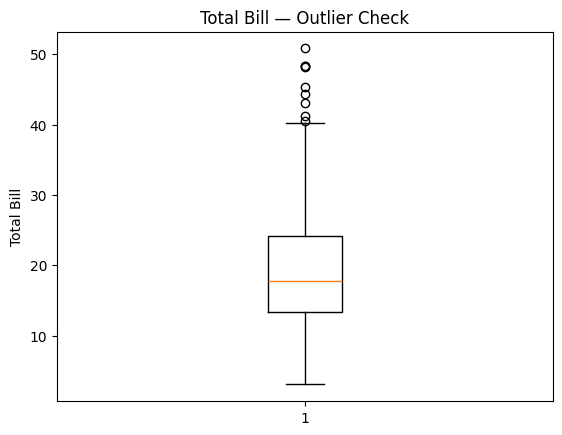

In [ ]:
# Visualize outliers with a boxplot
plt.figure()
plt.boxplot(tips['total_bill'])
plt.title("Total Bill — Outlier Check")
plt.ylabel("Total Bill")
plt.show()


### Student Practice

1. Run the same IQR outlier check on the `tip` column.
2. Instead of dropping outliers, **cap** them: replace any value above `upper_bound` with `upper_bound` itself, and any value below `lower_bound` with `lower_bound` (this is called "capping" or "winsorizing" — it keeps the row but limits the extreme value).


In [ ]:
Q1 = tips['tip'].quantile(0.25)
Q3 = tips['tip'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = tips[(tips['tip'] < lower_bound) | (tips['tip'] > upper_bound)]
print("Bounds:", lower_bound, upper_bound)
print("Number of outliers:", len(outliers))
outliers[['tip','day','size']]


Bounds: -0.34375 5.90625
Number of outliers: 9


,tip,day,size
23,7.58,Sat,4
47,6.00,Sun,4
59,6.73,Sat,4
141,6.70,Thur,6
170,10.00,Sat,3
183,6.50,Sun,4
212,9.00,Sat,4
214,6.50,Sat,3
239,5.92,Sat,3


In [ ]:
tips_capped = tips.copy()

tips_capped.loc[tips_capped['tip'] > upper_bound, 'tip'] = upper_bound
tips_capped.loc[tips_capped['tip'] < lower_bound, 'tip'] = lower_bound

tips_capped['tip'].describe()


,tip
count,244.000
mean,2.950
std,1.226
min,1.000
25%,2.000
50%,2.900
75%,3.562
max,5.906


**Reflection:** Why might capping outliers be preferable to simply dropping those rows? When would dropping be the better choice instead?

**Your answer:**
Capping outliers is often better because it keeps all the data rows while reducing the effect of extreme values, so you don’t lose information. Dropping rows might be better if the outliers are errors or irrelevant values that don’t represent the real data


## Part 5: Train/Test Split

Before training any model, data must be split so we can test performance on data the model has never seen. Splitting **after** all the preprocessing above ensures both sets are equally clean and encoded.

### Demonstration


In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)

tips_enc = tips.copy()
tips_enc['sex_encoded'] = tips_enc['sex'].map({'Male': 0, 'Female': 1})
tips_enc['smoker_encoded'] = tips_enc['smoker'].map({'No': 0, 'Yes': 1})
tips_enc['total_bill_scaled'] = (tips_enc['total_bill'] - tips_enc['total_bill'].min()) / (tips_enc['total_bill'].max() - tips_enc['total_bill'].min())

X = tips_enc[['total_bill_scaled','size','sex_encoded','smoker_encoded']]
y = tips_enc['tip_pct'] = tips_enc['tip'] / tips_enc['total_bill']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)



Train shape: (195, 4)
Test shape: (49, 4)


### Student Practice

1. Redo the split with `test_size=0.3` instead of 0.2. How many rows end up in the test set now?
2. Why do we set `random_state=42` (or any fixed number)? What would change if you removed it and ran the split twice?

    **Answer:**
    
    **Fixed random_state** → ensures the split is reproducible (same rows go into train/test every time).

    **Without random_state**→ each run gives a different random split, so train/test sets change every time.


In [3]:
from sklearn.model_selection import train_test_split

X = tips_enc[['total_bill_scaled','size','sex_encoded','smoker_encoded']]
y = tips_enc['tip_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (170, 4)
Test shape: (74, 4)


**Reflection:** Why is it important to split data **before** the model ever sees the test set, rather than training on all the data at once?

**Your answer:**

We split data before training so the model never sees the test set.

*   Test set acts like new, unseen data.
*   If we train on all data, the model just memorizes → results look good but are not real.

*   Keeping test data hidden gives a fair check of how the model will work in practice.


# Mini Project A: Image Preprocessing Pipeline (Image Track)

Raw image pixel values (0-255) are rarely fed directly into a model — they're almost always normalized first. You'll now apply real preprocessing to the images from your Week 2 mini-project.

## Step 1: Normalize pixel values

### Demonstration


In [6]:
from google.colab import files
uploaded = files.upload()


Saving rabbit.jpg to rabbit (1).jpg
Saving panda.jpg to panda.jpg
Saving squirrel.jpg to squirrel.jpg


In [5]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
sample_name = filenames[0]
img_array = np.array(Image.open(sample_name))

print("Original pixel range:", img_array.min(), "-", img_array.max())
print("Original dtype:", img_array.dtype)

# Normalize to 0-1 range (standard preprocessing step before feeding into a CNN)
img_normalized = img_array / 255.0

print("Normalized pixel range:", img_normalized.min(), "-", img_normalized.max())
print("Normalized dtype:", img_normalized.dtype)


Original pixel range: 0 - 255
Original dtype: uint8
Normalized pixel range: 0.0 - 1.0
Normalized dtype: float64


### Student Practice

1. Normalize **all** your uploaded images (loop over `filenames`) and store each normalized array in a list.
2. Build a small pandas DataFrame with columns `filename`, `min_pixel_before`, `max_pixel_before`, `min_pixel_after`, `max_pixel_after` to confirm normalization worked correctly across all images.


In [7]:
import pandas as pd
from PIL import Image
import numpy as np

rows = []
for fname in uploaded.keys():
    img_array = np.array(Image.open(fname))

    min_before, max_before = img_array.min(), img_array.max()

    img_normalized = img_array / 255.0

    min_after, max_after = img_normalized.min(), img_normalized.max()

    rows.append({
        "filename": fname,
        "min_pixel_before": min_before,
        "max_pixel_before": max_before,
        "min_pixel_after": min_after,
        "max_pixel_after": max_after
    })

df = pd.DataFrame(rows)
print(df)


         filename  min_pixel_before  max_pixel_before  min_pixel_after  \
0  rabbit (1).jpg                 0               255              0.0   
1       panda.jpg                 0               255              0.0   
2    squirrel.jpg                 0               255              0.0   

   max_pixel_after  
0              1.0  
1              1.0  
2              1.0  


## Step 2: Resize images to a consistent shape

Models need every input image to be the **same size**. Your uploaded images likely have different dimensions. Resizing standardizes this.

### Demonstration


In [8]:
target_size = (128, 128)

img_pil = Image.open(sample_name)
img_resized = img_pil.resize(target_size)
img_resized_array = np.array(img_resized)

print("Original shape:", img_array.shape)
print("Resized shape:", img_resized_array.shape)


Original shape: (3055, 3055, 3)
Resized shape: (128, 128, 3)


### Student Practice

Resize all your uploaded images to `(128, 128)`, normalize each to 0-1, and confirm every resulting array has the exact same shape using a pandas DataFrame (columns: `filename`, `shape`).


In [9]:
import pandas as pd
from PIL import Image
import numpy as np

target_size = (128, 128)
rows = []

for fname in uploaded.keys():

    img_resized = Image.open(fname).resize(target_size)
    img_array = np.array(img_resized)

    img_normalized = img_array / 255.0

    rows.append({
        "filename": fname,
        "shape": img_normalized.shape
    })

df = pd.DataFrame(rows)
print(df)



         filename          shape
0  rabbit (1).jpg  (128, 128, 3)
1       panda.jpg  (128, 128, 3)
2    squirrel.jpg  (128, 128, 3)


**Reflection:** Why must every image fed into a model have the exact same shape? What would happen if you tried to feed images of different sizes into the same model?

**Your answer:**
All images must have the same shape because models need fixed‑size inputs.
If sizes differ, the model cannot form proper tensors and training will fail.


# Mini Project B: Text Preprocessing Pipeline (NLP Track)

Just like images, raw text needs preprocessing before a model can use it: cleaning, and converting words into numeric IDs (since bag-of-words counts alone aren't how most modern NLP pipelines represent text).

## Step 1: Text cleaning

### Demonstration


In [10]:
raw_text = "NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day."

# Cleaning steps: lowercase, remove punctuation, tokenize
import re

cleaned = raw_text.lower()
cleaned = re.sub(r'[^a-z0-9\s]', '', cleaned)  # remove punctuation
tokens = cleaned.split()

print("Before:", raw_text)
print("After:", tokens)


Before: NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day.
After: ['numpy', 'pandas', 'and', 'scikitlearn', 'are', 'amazing', 'tools', 'i', 'use', 'numpy', 'every', 'day']


### Student Practice

Write your own messy sentence (include punctuation, capital letters, maybe a number). Clean it using the same pattern and print the resulting tokens.


In [11]:
import re

raw_text = "ML!!! with Python & Data is AMAZING, I love it :)"

cleaned = raw_text.lower()
cleaned = re.sub(r'[^a-z0-9\s]', '', cleaned)
tokens = cleaned.split()

print("Before:", raw_text)
print("After:", tokens)


Before: ML!!! with Python & Data is AMAZING, I love it :)
After: ['ml', 'with', 'python', 'data', 'is', 'amazing', 'i', 'love', 'it']


## Step 2: Encoding words as numeric IDs

Models need numbers, not words. We'll build a **word-to-ID mapping** (a simple form of what's called a "vocabulary index" — the first step toward embeddings).

### Demonstration


In [12]:
vocabulary = sorted(set(tokens))
word_to_id = {word: idx for idx, word in enumerate(vocabulary)}

print("Word to ID mapping:", word_to_id)

encoded_tokens = [word_to_id[word] for word in tokens]
print("Original tokens:", tokens)
print("Encoded as IDs:  ", encoded_tokens)


Word to ID mapping: {'amazing': 0, 'data': 1, 'i': 2, 'is': 3, 'it': 4, 'love': 5, 'ml': 6, 'python': 7, 'with': 8}
Original tokens: ['ml', 'with', 'python', 'data', 'is', 'amazing', 'i', 'love', 'it']
Encoded as IDs:   [6, 8, 7, 1, 3, 0, 2, 5, 4]


### Student Practice

1. Build a `word_to_id` mapping for the tokens from your Step 1 sentence.
2. Encode your tokens into a list of numeric IDs.
3. Build a pandas DataFrame with columns `word` and `id` showing the full mapping, sorted by `id`.


In [13]:
import pandas as pd

tokens = ['ml', 'with', 'python', 'data', 'is', 'amazing', 'i', 'love', 'it']

vocabulary = sorted(set(tokens))
word_to_id = {word: idx for idx, word in enumerate(vocabulary)}

encoded_tokens = [word_to_id[word] for word in tokens]

df = pd.DataFrame(list(word_to_id.items()), columns=['word', 'id']).sort_values('id').reset_index(drop=True)

print("Word to ID mapping:", word_to_id)
print("Original tokens:", tokens)
print("Encoded as IDs:", encoded_tokens)
print("\nDataFrame:\n", df)


Word to ID mapping: {'amazing': 0, 'data': 1, 'i': 2, 'is': 3, 'it': 4, 'love': 5, 'ml': 6, 'python': 7, 'with': 8}
Original tokens: ['ml', 'with', 'python', 'data', 'is', 'amazing', 'i', 'love', 'it']
Encoded as IDs: [6, 8, 7, 1, 3, 0, 2, 5, 4]

DataFrame:
       word  id
0  amazing   0
1     data   1
2        i   2
3       is   3
4       it   4
5     love   5
6       ml   6
7   python   7
8     with   8


**Reflection:** This word-to-ID encoding is similar to label encoding from Part 2. What potential problem could this cause if fed directly into a model (Hint: think about the "misleading order" issue from Part 2 — does the same issue apply to words)?

**Your answer:**

Word‑to‑ID encoding is like label encoding: it assigns numbers to categories.

The problem is that the IDs create a false sense of order (e.g., “amazing=0” and “ml=6” makes it look like ml is “greater” than amazing).

If fed directly into a model, the network might wrongly assume numeric relationships between words that don’t exist.


# Final Self-Check

- [ ] I handled missing data using a justified strategy, not just dropped everything blindly
- [ ] I correctly chose label encoding vs one-hot encoding based on whether categories have order
- [ ] I scaled numeric features and can explain the difference between min-max and standardization
- [ ] I detected outliers using IQR and handled them (capped, not just deleted)
- [ ] I split data into train/test sets correctly
- [ ] I completed Mini Project A (image normalization/resizing) or B (text cleaning/encoding)
- [ ] I answered all reflection questions in my own words

## Final Reflection Questions

1. Put the preprocessing steps in this lab in the order you'd typically apply them to a raw dataset, and briefly justify the order.           

   **Ans:** Handle missing data → Encode categorical variables → Scale numeric features → Detect & handle outliers → Split train/test → Apply domain‑specific preprocessing (images/text).  

2. Why is preprocessing considered part of "data work," and not something a model does automatically?

   **Ans:** Because models only consume numbers — they don’t know how to clean, encode, or scale raw data. Preprocessing is the human/data scientist’s job to make inputs consistent and meaningful before training.


3. Compare preprocessing images (Mini Project A) vs preprocessing text (Mini Project B). What's conceptually similar between normalizing pixels and encoding words as IDs?

     **Ans:** Preprocessing images (Mini Project A) and text (Mini Project B) are conceptually similar because both take messy raw input and convert it into uniform numeric representations that models can understand.

     **Images:** Pixels are normalized (e.g., scaled to 0–1) and resized so every image has the same shape.

      **Text:** Words are cleaned into tokens and encoded as numeric IDs.

     The similarity is that both steps remove inconsistencies and transform human‑readable data (pictures or words) into a consistent numeric format. This ensures the model sees structured input instead of raw, messy data.

4. What's one preprocessing concept from this lab you still feel unsure about? Be specific.
  